In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 5** - Chemical Process Optimisation (4D)

- A black-box function representing the yield of a chemical process in a factory. 
- The function is typically unimodal, one peak, no traps.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield.

**Input** - 4D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 6605.98 at [0.871, 0.993, 1.000, 1.000] (Week 11)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 5
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

# New data from Week 11 (Function 5)
X_w11_new_point = np.array([0.871213, 0.992883, 1.0, 1.0], dtype=np.float64)
Y_w11_new_point = np.array([6605.983806747145], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w11_new_point.reshape(1, -1)))

# Remove duplicate X rows
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w11_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.004861   0.982935   0.98162    0.958237  ]
 [0.028538   0.096927   0.128764   0.401407  ]
 [0.114475   0.992539   0.999989   0.525254  ]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.221849   0.896815   0.894595   0.898055  ]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.

## **Output Analysis**

- This week I got the output of 6605.98 (all-time best), which was a definite improvement from last week's (w10) 6203.50.
    - w11's query [0.871, 0.993, 1.000, 1.000] pushed x3 and x4 to their absolute maximum (1.000) while x1 increased slightly (0.871 vs 0.843) and x2 held near its maximum. 
    - The function is clearly responding well to all inputs near their upper boundary.

- **Real-World Implication:** The consecutive new highs (5896 → 6203 → 6606) confirm this is a smooth unimodal function and we are ascending its slope toward the true global maximum. 
    - In chemical engineering terms, the reaction is in its most efficient as all inputs at or near saturation are producing exponentially better yield.

- **Model Clues:** With x3 and x4 now at 1.000, further improvement must come from fine-tuning x1 (currently 0.871) and x2 (0.993). 
    - The pattern suggests x1 continuing to increase slightly each week is beneficial. 
    - w12 will try a slightly higher x1 (~0.90) while holding x2, x3, x4 near their current values.

## **Bayesian Optimisation**

- **Model:** Matern (nu=2.5) + WhiteKernel + Yeo-Johnson. 
    - Unchanged as it has helped get consecutive improvements confirm it.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=20)
    
model.fit(X_unique, Y_transformed)

Original Y: [3.47588113e+03 1.42925081e+02 1.72816974e+03 4.31612757e+02
 9.97233189e+00 8.84799176e+00 6.44434399e+01 1.52269614e+03
 1.08885962e+03 1.33955718e+03 6.34767158e+01 1.09571876e+02
 4.51815703e+01 1.12939795e-01 3.55806818e+02 2.33223610e+02
 7.97291299e+01 5.75715369e+01 1.55727657e+02 6.44201468e+01
 2.44230883e+01 7.84343889e+01 4.21089813e+00 2.88667516e+01
 1.83013796e+01 2.58370525e+02 5.22126375e+03 6.20349673e+03
 5.89609014e+03 6.60598381e+03 3.44506661e+03]
Transformed Y: [ 1.28972691 -0.14383096  0.96938528  0.3438311  -1.25328749 -1.29895229
 -0.48811416  0.91172864  0.75953254  0.85347666 -0.49457616 -0.25945116
 -0.63910338 -2.20419262  0.25788251  0.07095848 -0.39681273 -0.53624977
 -0.10635878 -0.48826875 -0.89581127 -0.40385528 -1.56631088 -0.82676219
 -1.0135065   0.11613831  1.47784883  1.55789696  1.53427324  1.58714193
  1.28562297]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Key change:** Centre on W11 best [0.871, 0.993, 1.000, 1.000] but slightly bias x1 upward. 
    - x1 has been increasing each week (0.843 → 0.846 → 0.871) and each increase has produced a better result.

In [4]:
def expected_improvement(X, model, y_max, xi=0.0005):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w11_best = np.array([0.871213, 0.992883, 1.0, 1.0])
x_grid = np.random.normal(loc=w11_best, scale=0.008, size=(9500, 4))

x_uniform = np.random.uniform(0, 1, size=(500, 4))

x_grid = np.vstack([x_grid, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)

ei_values = expected_improvement(x_grid, model, y_max, xi=0.0005)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w11_best}')
print(f'Strategic Week 12 Query (Function 5): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

Best coordinates: [0.871213 0.992883 1.       1.      ]
Strategic Week 12 Query (Function 5): 0.990432-0.741174-0.968413-0.995092


## **Visualisation**

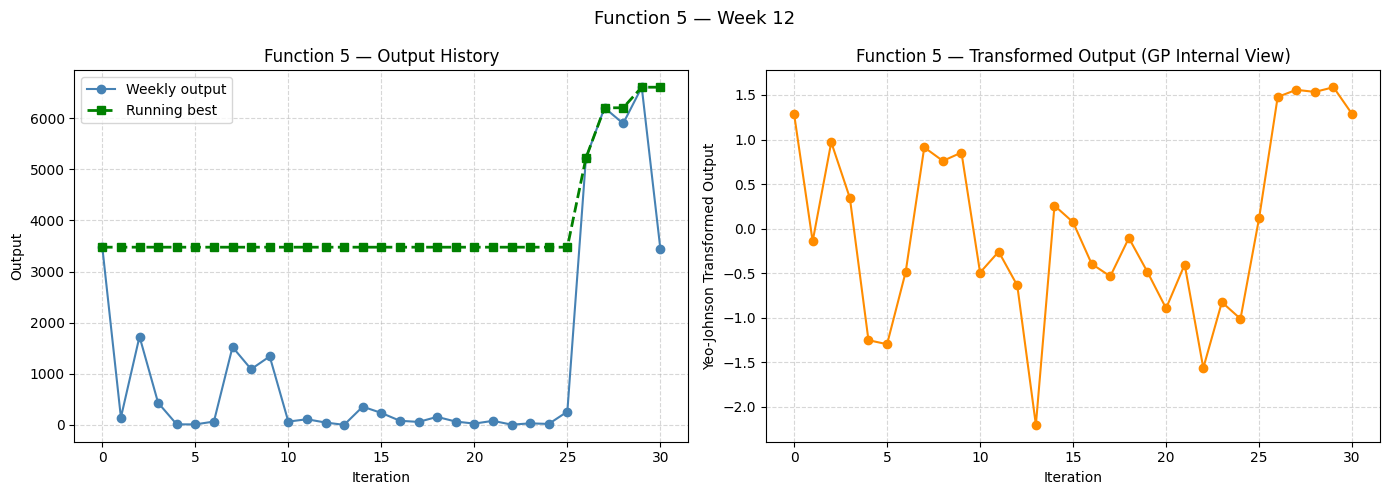

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 5 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 5 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 5 — Week 12', fontsize=13)
plt.tight_layout()
plt.show()